In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from ucimlrepo import fetch_ucirepo
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import json

# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
# data (as pandas dataframes) 
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 
  
# metadata 
print(cdc_diabetes_health_indicators.metadata) 
  
# variable information 
print(cdc_diabetes_health_indicators.variables) 

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

In [2]:
X

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1,1,1,40,1,0,0,0,0,1,0,1,0,5,18,15,1,0,9,4,3
1,0,0,0,25,1,0,0,1,0,0,0,0,1,3,0,0,0,0,7,6,1
2,1,1,1,28,0,0,0,0,1,0,0,1,1,5,30,30,1,0,9,4,8
3,1,0,1,27,0,0,0,1,1,1,0,1,0,2,0,0,0,0,11,3,6
4,1,1,1,24,0,0,0,1,1,1,0,1,0,2,3,0,0,0,11,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1,1,1,45,0,0,0,0,1,1,0,1,0,3,0,5,0,1,5,6,7
253676,1,1,1,18,0,0,0,0,0,0,0,1,0,4,0,0,1,0,11,2,4
253677,0,0,1,28,0,0,0,1,1,0,0,1,0,1,0,0,0,0,2,5,2
253678,1,0,1,23,0,0,0,0,1,1,0,1,0,3,0,0,0,1,7,5,1


In [3]:
y

,Diabetes_binary
0,0
1,0
2,0
3,0
4,0
...,...
253675,0
253676,1
253677,0
253678,0


In [4]:
y.value_counts()

Diabetes_binary
0                  218334
1                   35346
Name: count, dtype: int64

In [5]:
# =====================================
# 3. Inspect & Prepare Data
# =====================================

# Usually, the target column is 'Diabetes_binary'
target_col = "Diabetes_binary"

# Most columns are already numeric/binary
# We'll just standardize continuous columns like BMI, Age, Income, etc.

continuous_cols = ["BMI", "Age", "Income"]
scaler = StandardScaler()
X[continuous_cols] = scaler.fit_transform(X[continuous_cols])

# Train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


/tmp/ipykernel_2488119/3184645927.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[continuous_cols] = scaler.fit_transform(X[continuous_cols])


Train: (177576, 21), Val: (38052, 21), Test: (38052, 21)


/home/duje/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01/20 | Train Loss: 0.0331 | Val Loss: 0.0317
Epoch 02/20 | Train Loss: 0.0316 | Val Loss: 0.0316
Epoch 03/20 | Train Loss: 0.0315 | Val Loss: 0.0314
Epoch 04/20 | Train Loss: 0.0315 | Val Loss: 0.0314
Epoch 05/20 | Train Loss: 0.0315 | Val Loss: 0.0314
Epoch 06/20 | Train Loss: 0.0314 | Val Loss: 0.0314
Epoch 07/20 | Train Loss: 0.0315 | Val Loss: 0.0313
Epoch 08/20 | Train Loss: 0.0315 | Val Loss: 0.0314
Epoch 09/20 | Train Loss: 0.0314 | Val Loss: 0.0314
Epoch 10/20 | Train Loss: 0.0314 | Val Loss: 0.0315
Epoch 11/20 | Train Loss: 0.0315 | Val Loss: 0.0313
Epoch 12/20 | Train Loss: 0.0313 | Val Loss: 0.0313
Epoch 13/20 | Train Loss: 0.0313 | Val Loss: 0.0313
Epoch 14/20 | Train Loss: 0.0313 | Val Loss: 0.0312
Epoch 15/20 | Train Loss: 0.0313 | Val Loss: 0.0312
Epoch 16/20 | Train Loss: 0.0313 | Val Loss: 0.0312
Epoch 17/20 | Train Loss: 0.0313 | Val Loss: 0.0312
Epoch 18/20 | Train Loss: 0.0312 | Val Loss: 0.0312
Epoch 19/20 | Train Loss: 0.0312 | Val Loss: 0.0312
Epoch 20/20 

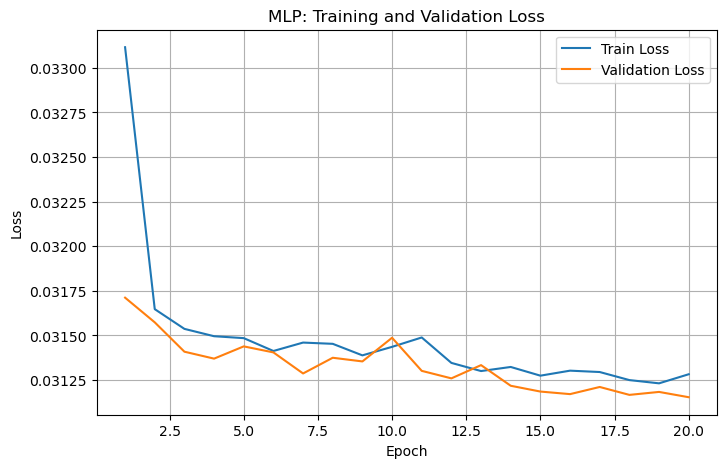

In [ ]:
# =====================================
# MLP: train on (X_train, y_train), validate on (X_val, y_val),
#       evaluate on NORMAL (imbalanced) (X_test, y_test)
# =====================================

# ---------- Reproducibility ----------
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# ---------- Datasets / Dataloaders ----------
def to_tensor_dataset(X, y):
    X_tensor = torch.tensor(X.values, dtype=torch.float32)
    y_tensor = torch.tensor(y.values.flatten(), dtype=torch.long)
    return TensorDataset(X_tensor, y_tensor)

train_ds = to_tensor_dataset(X_train, y_train)
val_ds   = to_tensor_dataset(X_val, y_val)
test_ds  = to_tensor_dataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=1024, shuffle=False, num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=1024, shuffle=False, num_workers=0, pin_memory=True)

# ---------- Model ----------
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train.shape[1]
model = MLP(input_dim).to(device)

# ---------- Loss: Focal Loss (multi-class, γ=2) ----------
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        # alpha: per-class weight tensor of shape [C] (optional)
        self.alpha = alpha

    def forward(self, logits, target):
        # logits: [N, C], target: [N]
        log_probs = F.log_softmax(logits, dim=1)              # [N, C]
        probs = torch.exp(log_probs)                          # [N, C]

        # gather the log-prob and prob of the target class
        log_pt = log_probs.gather(1, target.unsqueeze(1)).squeeze(1)  # [N]
        pt = probs.gather(1, target.unsqueeze(1)).squeeze(1)          # [N]

        # focal modulation
        focal_factor = (1 - pt).pow(self.gamma)                       # [N]
        loss = -focal_factor * log_pt                                  # [N]

        # class weighting (alpha) if provided
        if self.alpha is not None:
            at = self.alpha.gather(0, target)                         # [N]
            loss = at * loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

# compute per-class alpha from class imbalance (normalized)
cls_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train.values.flatten()
)  # shape [2], higher weight for the minority class
alpha = torch.tensor(cls_weights / cls_weights.sum(), dtype=torch.float32, device=device)

# use focal loss instead of CrossEntropyLoss
criterion = FocalLoss(alpha=alpha, gamma=2.0, reduction='mean')

# ---------- Optimizer / Scheduler ----------
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)

# ---------- Train / Validate helpers ----------
def run_epoch(dl, train=True):
    if train:
        model.train()
    else:
        model.eval()
    total_loss, total_count = 0.0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            total_count += xb.size(0)
    return total_loss / max(total_count, 1)

@torch.no_grad()
def predict_proba(dl):
    model.eval()
    probs, labels = [], []
    softmax = nn.Softmax(dim=1)
    for xb, yb in dl:
        xb = xb.to(device)
        logits = model(xb)
        p = softmax(logits)[:, 1].detach().cpu().numpy()  # prob of class 1
        probs.append(p)
        labels.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(labels)

# ---------- Training Loop with Early Stopping ----------
num_epochs = 20
patience = 7
best_val = float("inf")
best_state = None
pat_ctr = 0

train_losses, val_losses = [], []

for epoch in range(1, num_epochs + 1):
    tr_loss = run_epoch(train_dl, train=True)
    val_loss = run_epoch(val_dl, train=False)
    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    # Save model weights as JSON each epoch
    state_dict = model.state_dict()

    # Convert tensors to Python lists
    state_dict_json = {k: v.cpu().tolist() for k, v in state_dict.items()}

    with open(f"mlp_epoch_{epoch:02d}.json", "w") as f:
        json.dump(state_dict_json, f)
    
    scheduler.step(val_loss)
    print(f"Epoch {epoch:02d}/{num_epochs} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val - 1e-6:
        best_val = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        pat_ctr = 0
    else:
        pat_ctr += 1
        if pat_ctr >= patience:
            print("Early stopping triggered.")
            break

# Load best weights
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

# ---------- Plot Train/Val Loss ----------
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP: Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
for epoch in range(1, num_epochs + 1):
    tr_loss = run_epoch(train_dl, train=True)
    val_loss = run_epoch(val_dl, train=False)
    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    torch.save(model.state_dict(), f"mlp_epoch_{epoch:02d}.pt")
    
    scheduler.step(val_loss)
    print(f"Epoch {epoch:02d}/{num_epochs} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val - 1e-6:
        best_val = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        pat_ctr = 0
    else:
        pat_ctr += 1
        if pat_ctr >= patience:
            print("Early stopping triggered.")
            break

# Load best weights
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

# ---------- Plot Train/Val Loss ----------
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP: Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# ---------- Final Evaluation on NORMAL test set ----------
y_proba_test, y_true_test = predict_proba(test_dl)
y_pred_test = (y_proba_test >= 0.52).astype(int)

print("\n=== MLP Evaluation on NORMAL (imbalanced) Test Set ===")
print("Accuracy:", accuracy_score(y_true_test, y_pred_test))
print("ROC-AUC:", roc_auc_score(y_true_test, y_proba_test))
print("\nClassification Report:\n", classification_report(y_true_test, y_pred_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_true_test, y_pred_test))


# ---------- Final Evaluation on BALANCED test set ----------
from imblearn.over_sampling import RandomOverSampler

# Balance the test set using random oversampling
ros = RandomOverSampler(random_state=42)
X_test_bal, y_test_bal = ros.fit_resample(X_test, y_test.values.ravel())

# Convert to DataLoader
test_bal_ds = TensorDataset(torch.tensor(X_test_bal.values, dtype=torch.float32),
                            torch.tensor(y_test_bal, dtype=torch.long))
test_bal_dl = DataLoader(test_bal_ds, batch_size=1024, shuffle=False)

# Evaluate
y_proba_test_bal, y_true_test_bal = predict_proba(test_bal_dl)
y_pred_test_bal = (y_proba_test_bal >= 0.52).astype(int)

print("\n=== MLP Evaluation on BALANCED Test Set ===")
print("Accuracy:", accuracy_score(y_true_test_bal, y_pred_test_bal))
print("ROC-AUC:", roc_auc_score(y_true_test_bal, y_proba_test_bal))
print("\nClassification Report:\n", classification_report(y_true_test_bal, y_pred_test_bal))
print("\nConfusion Matrix:\n", confusion_matrix(y_true_test_bal, y_pred_test_bal))



=== MLP Evaluation on NORMAL (imbalanced) Test Set ===
Accuracy: 0.7462945443077893
ROC-AUC: 0.8289289307506026

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.74      0.83     32750
           1       0.32      0.76      0.45      5302

    accuracy                           0.75     38052
   macro avg       0.64      0.75      0.64     38052
weighted avg       0.86      0.75      0.78     38052


Confusion Matrix:
 [[24369  8381]
 [ 1273  4029]]

=== MLP Evaluation on BALANCED Test Set ===
Accuracy: 0.7523969465648855
ROC-AUC: 0.8291052022609405

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.74      0.75     32750
           1       0.75      0.76      0.75     32750

    accuracy                           0.75     65500
   macro avg       0.75      0.75      0.75     65500
weighted avg       0.75      0.75      0.75     65500


Confusion Matrix:
 [[24369  8

/home/duje/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


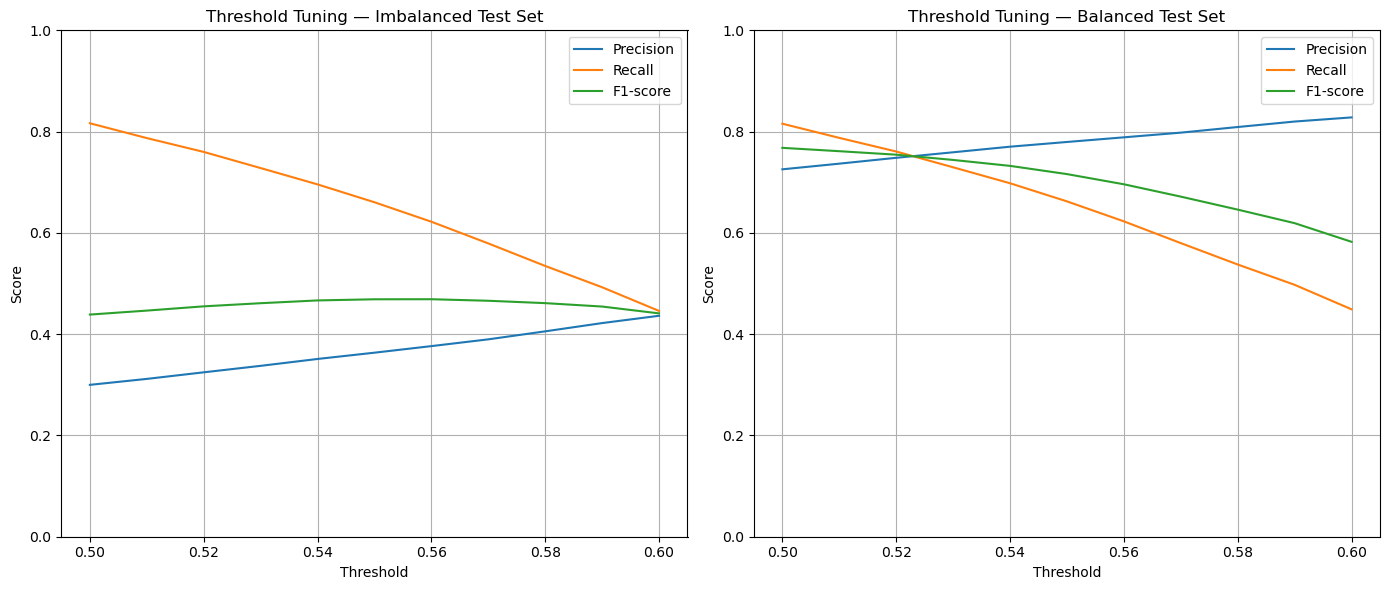

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate thresholds
thresholds = np.arange(0.5, 0.61, 0.01)
precision_imb, recall_imb, f1_imb = [], [], []
precision_bal, recall_bal, f1_bal = [], [], []

# ---------- IMBALANCED SET ----------
y_proba_test, y_true_test = predict_proba(test_dl)

# ---------- BALANCED SET ----------
y_proba_test_bal, y_true_test_bal = predict_proba(test_bal_dl)

for thr in thresholds:
    # Imbalanced
    y_pred_test = (y_proba_test >= thr).astype(int)
    precision_imb.append(precision_score(y_true_test, y_pred_test))
    recall_imb.append(recall_score(y_true_test, y_pred_test))
    f1_imb.append(f1_score(y_true_test, y_pred_test))
    
    # Balanced
    y_pred_test_bal = (y_proba_test_bal >= thr).astype(int)
    precision_bal.append(precision_score(y_true_test_bal, y_pred_test_bal))
    recall_bal.append(recall_score(y_true_test_bal, y_pred_test_bal))
    f1_bal.append(f1_score(y_true_test_bal, y_pred_test_bal))

# ---------- PLOTS ----------
plt.figure(figsize=(14, 6))

# Imbalanced set
plt.subplot(1, 2, 1)
plt.plot(thresholds, precision_imb, label='Precision')
plt.plot(thresholds, recall_imb, label='Recall')
plt.plot(thresholds, f1_imb, label='F1-score')
plt.title("Threshold Tuning — Imbalanced Test Set")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

# Balanced set
plt.subplot(1, 2, 2)
plt.plot(thresholds, precision_bal, label='Precision')
plt.plot(thresholds, recall_bal, label='Recall')
plt.plot(thresholds, f1_bal, label='F1-score')
plt.title("Threshold Tuning — Balanced Test Set")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


/home/duje/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


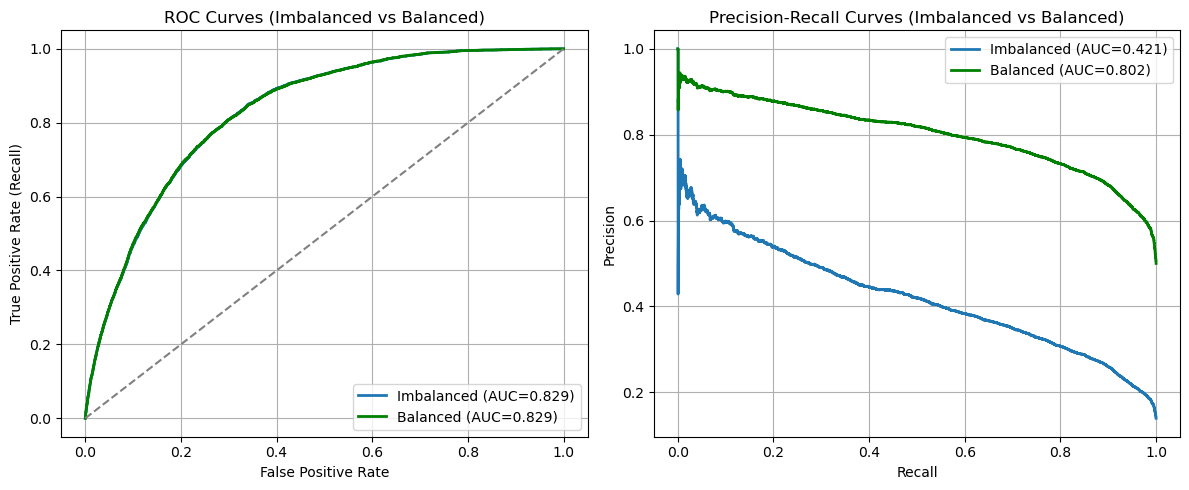

Imbalanced Optimal threshold (F1): 0.559
Imbalanced Optimal threshold (F2): 0.487


In [9]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

# --- Get predictions for imbalanced and balanced test sets ---
y_proba_imbal, y_true_imbal = predict_proba(test_dl)
y_proba_bal, y_true_bal = predict_proba(test_bal_dl)

# --- Compute curves for both ---
def compute_curves(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    precision, recall, thresholds_pr = precision_recall_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)
    return fpr, tpr, thresholds, precision, recall, thresholds_pr, roc_auc, pr_auc

fpr_i, tpr_i, thr_i, prec_i, rec_i, thr_pr_i, roc_i, pr_i = compute_curves(y_true_imbal, y_proba_imbal)
fpr_b, tpr_b, thr_b, prec_b, rec_b, thr_pr_b, roc_b, pr_b = compute_curves(y_true_bal, y_proba_bal)

# --- Compute F1/F2 optimal thresholds (imbalanced only, example) ---
f1_i = 2 * (prec_i * rec_i) / (prec_i + rec_i + 1e-8)
f2_i = (5 * prec_i * rec_i) / (4 * prec_i + rec_i + 1e-8)
best_f1_i = thr_pr_i[np.argmax(f1_i)]
best_f2_i = thr_pr_i[np.argmax(f2_i)]

# =====================================
# ROC Curves: Balanced vs Imbalanced
# =====================================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr_i, tpr_i, label=f'Imbalanced (AUC={roc_i:.3f})', lw=2)
plt.plot(fpr_b, tpr_b, label=f'Balanced (AUC={roc_b:.3f})', lw=2, color='green')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves (Imbalanced vs Balanced)')
plt.legend()
plt.grid(True)

# =====================================
# Precision-Recall Curves: Balanced vs Imbalanced
# =====================================
plt.subplot(1,2,2)
plt.plot(rec_i, prec_i, label=f'Imbalanced (AUC={pr_i:.3f})', lw=2)
plt.plot(rec_b, prec_b, label=f'Balanced (AUC={pr_b:.3f})', lw=2, color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves (Imbalanced vs Balanced)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Imbalanced Optimal threshold (F1): {best_f1_i:.3f}")
print(f"Imbalanced Optimal threshold (F2): {best_f2_i:.3f}")


In [ ]:
#Model loading

#model = torch.load("mlp_full_epoch_10.pt")
#model.eval()

In [12]:
# Load state_dict
state_dict = torch.load("mlp_epoch_10.pt", map_location="cpu")

# Convert to JSON
state_dict_json = {k: v.tolist() for k, v in state_dict.items()}

# Save as JSON
with open("mlp_epoch_10.json", "w") as f:
    json.dump(state_dict_json, f)

In [13]:
def average_models(local_model, received_model_path, save_path=None):

    # Load the received model state_dict
    received_state = torch.load(received_model_path, map_location="cpu")

    # Get local model state_dict
    local_state = local_model.state_dict()

    # Average parameters
    averaged_state = {}
    for key in local_state.keys():
        averaged_state[key] = (local_state[key].cpu() + received_state[key].cpu()) / 2.0

    # Load averaged weights into local model
    local_model.load_state_dict(averaged_state)

    # Optionally save the averaged model
    if save_path:
        torch.save(local_model.state_dict(), save_path)

    return local_model